In [11]:
import numpy as np
import matplotlib.pyplot as plt
import json


In [16]:
data_path = r"C:\Users\loy49\Desktop\REPO\Multi_Head_HRC\data\dataset\dataset_lift.npz"
data = np.load(data_path)

labels_path = r"C:\Users\loy49\Desktop\REPO\Multi_Head_HRC\data\dataset\labels_lift.json"
with open(labels_path, "r") as f:
    labels = json.load(f)

In [13]:
#header = ["frame_idx","X_pose", "X_step", "X_elem", "X_env", "Y_type", "Y_urgency", "Y_eta"]
X_pose = data["X_pose"]  # [num_frames, pose_dim]
X_step = data["X_step"]  # [num_frames, step_dim]
X_elem = data["X_elem"]  # [num_frames, elem_dim]
X_env = data["X_env"]    # [num_frames, env_dim]
Y_type = data["Y_type"]  # [num_frames]
Y_urgency = data["Y_urgency"]  # [num_frames]
Y_eta = data["Y_eta"]    # [num_frames]
print("X_pose shape:", X_pose.shape)
print("X_step shape:", X_step.shape)
print("X_elem shape:", X_elem.shape)
print("X_env shape:", X_env.shape)
print("Y_type shape:", Y_type.shape)
print("Y_urgency shape:", Y_urgency.shape)
print("Y_eta shape:", Y_eta.shape)


X_pose shape: (520, 132)
X_step shape: (520,)
X_elem shape: (520, 0)
X_env shape: (520, 0)
Y_type shape: (520,)
Y_urgency shape: (520,)
Y_eta shape: (520,)


In [4]:
Y_eta

array([ 3.367,  2.867,  2.367,  1.867,  1.367,  0.867,  0.367,  0.   ,
        0.   ,  0.   ,  0.5  ,  1.   ,  1.5  ,  2.   ,  2.5  ,  3.   ,
        3.5  ,  4.   ,  4.5  ,  5.   ,  5.5  ,  6.   ,  6.5  ,  7.   ,
        7.5  ,  8.   ,  8.5  ,  9.   ,  9.5  , 10.   , 10.5  , 11.   ,
       11.5  , 12.   ], dtype=float32)

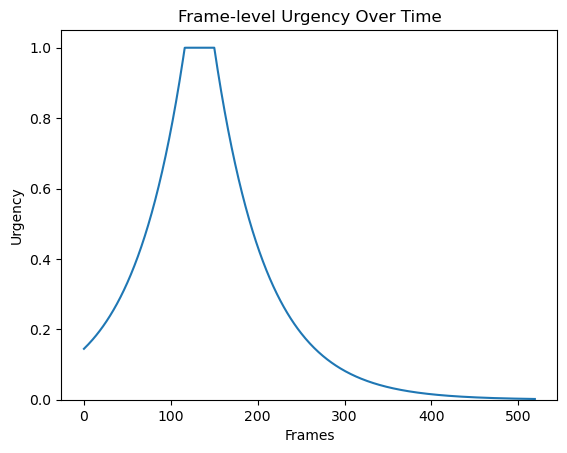

In [25]:
Y_urgency = data["Y_urgency"]          # [N_windows]
               # [N_windows]
total_frames = X_pose.shape[0]

# ===== 3. Build frame-level urgency =====
frame_urgency = np.zeros(total_frames)

for i in range(total_frames):
    frame_urgency[i] = Y_urgency[i]

# # ===== 5. Plot =====
plt.figure()
plt.plot(frame_urgency, label="Frame-level Urgency")
plt.xlabel("Frames")
plt.ylabel("Urgency")
plt.title("Frame-level Urgency Over Time")
plt.ylim(0, 1.05)
plt.show()

In [26]:
for k in data.files:
    arr = data[k]
    print(f"{k}:")
    print("  shape:", arr.shape)
    print("  dtype:", arr.dtype)
    print("  sample values:", arr.flatten()[:5])
    print("-" * 40)

X_pose:
  shape: (520, 132)
  dtype: float32
  sample values: [ 0.36097     0.40297043 -0.11216961  0.9980869   0.37645233]
----------------------------------------
X_step:
  shape: (520,)
  dtype: int64
  sample values: [3 3 3 3 3]
----------------------------------------
X_elem:
  shape: (520, 0)
  dtype: float32
  sample values: []
----------------------------------------
X_env:
  shape: (520, 0)
  dtype: float32
  sample values: []
----------------------------------------
Y_type:
  shape: (520,)
  dtype: int64
  sample values: [0 0 0 0 0]
----------------------------------------
Y_urgency:
  shape: (520,)
  dtype: float32
  sample values: [0.14464107 0.14707196 0.14954369 0.15205698 0.1546125 ]
----------------------------------------
Y_eta:
  shape: (520,)
  dtype: float32
  sample values: [3.867     3.8336666 3.8003333 3.767     3.7336667]
----------------------------------------
pose_dim:
  shape: ()
  dtype: int64
  sample values: [132]
----------------------------------------


In [27]:
data.files

['X_pose',
 'X_step',
 'X_elem',
 'X_env',
 'Y_type',
 'Y_urgency',
 'Y_eta',
 'pose_dim',
 'elem_dim',
 'env_dim',
 'fps',
 'urgency_lambda']